In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
cd /content/drive/MyDrive/

/content/drive/MyDrive


In [7]:
ls

'Colab Notebooks'/   __MACOSX/     taxi_drop/
 KDD2022@            nyc-taxi.h5   taxi_drop.zip


# 读取h5历史交通流量数据并观察数据结构

In [8]:
import h5py

# 打开文件
with h5py.File('nyc-taxi.h5', 'r') as f:
    # 打印顶层所有的 key
    print("Keys in the file:", list(f.keys()))
    
    # 递归查看数据集的 shape 和 dtype
    def print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"Dataset: {name}, Shape: {obj.shape}, Type: {obj.dtype}")

    f.visititems(print_structure)

Keys in the file: ['taxi_drop', 'taxi_pick']
Dataset: taxi_drop, Shape: (4368, 266), Type: int64
Dataset: taxi_pick, Shape: (4368, 266), Type: int64


# 构建含气象信息的交通流量数据集

In [ ]:
import requests
import pandas as pd

def weather_info(start_date = "2016-04-01", end_date = "2016-06-30", lat= 40.7128, lon= -74.0060):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "precipitation",
        "timezone": "America/New_York"
    }
    print(f"正在获取天气数据：{start_date} 至 {end_date} 的NYC历史天气")

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()  # 如果请求失败，会抛出异常

    hourly_data = response.json().get("hourly", {})
    df_hourly = pd.DataFrame({
            "precipitation": hourly_data.get("precipitation", []),   # 单位：mm/h
        },
        index = pd.to_datetime(hourly_data.get("time", [])),  # 逐小时 DatetimeIndex（本地时区）
    )

    idx_30 = pd.date_range(
        start=df_hourly.index[0],
        periods = 4368,
        freq="30min",
    )
    df_30 = df_hourly.reindex(idx_30)  # 先 reindex（整点有值，半点为 NaN），再分别填充
    df_30["precipitation"] = df_hourly["precipitation"].reindex(idx_30, method="ffill") * 0.5  # 向前填充

    return df_30

#测试weather info函数
# df_weather = weather_info()
# df_weather.shape #(4368, 1)

正在获取天气数据：2016-04-01 至 2016-06-30 的NYC历史天气


(4368, 1)

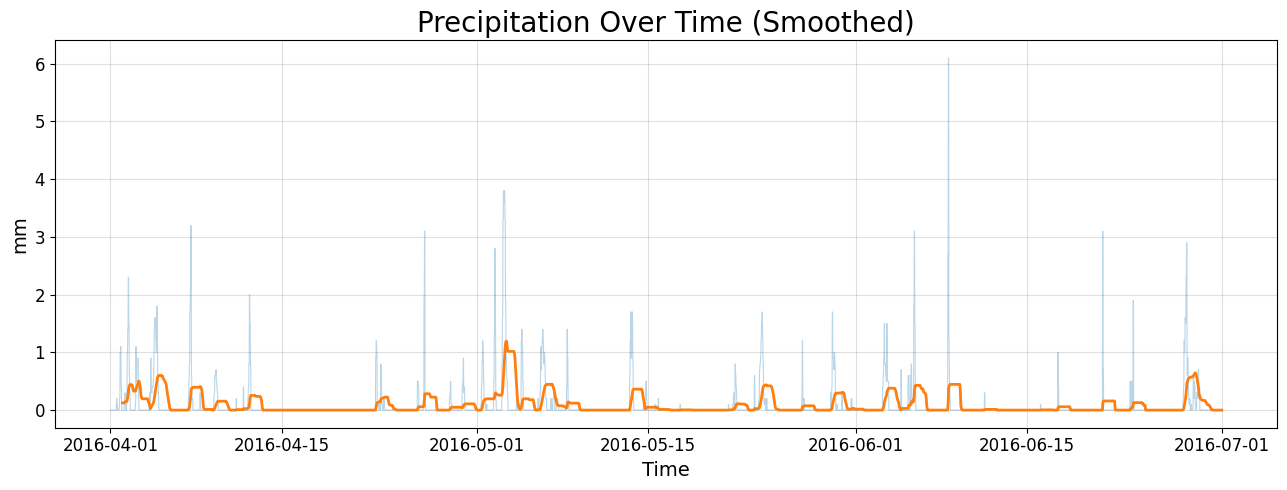

In [ ]:
# import matplotlib.pyplot as plt    
# plt.figure(figsize=(13, 5))

# plt.plot(df_weather.index, df_weather["precipitation"], alpha=0.3, linewidth=0.8)

# smooth = df_weather["precipitation"].rolling(48).mean()
# plt.plot(df_weather.index, smooth, linewidth=2)

# 
# plt.title("Precipitation Over Time (Smoothed)", fontsize=20)
# plt.xlabel("Time", fontsize=14)
# plt.ylabel("mm", fontsize=14)

# 
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.grid(alpha=0.4)
# plt.tight_layout()
# plt.show()



Rainy days: 46
Non-rainy days: 45


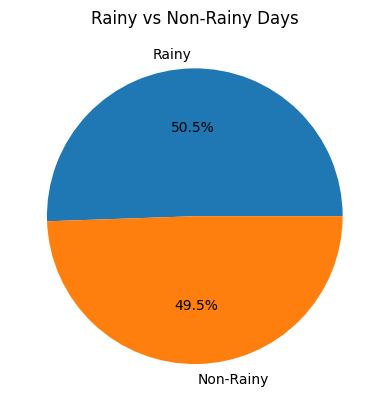

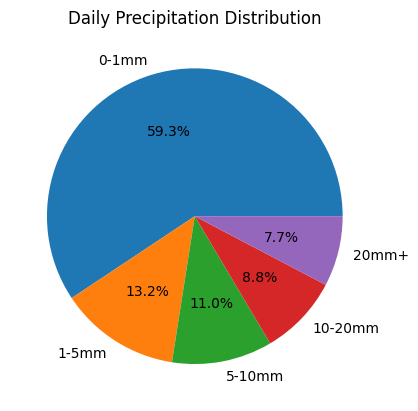

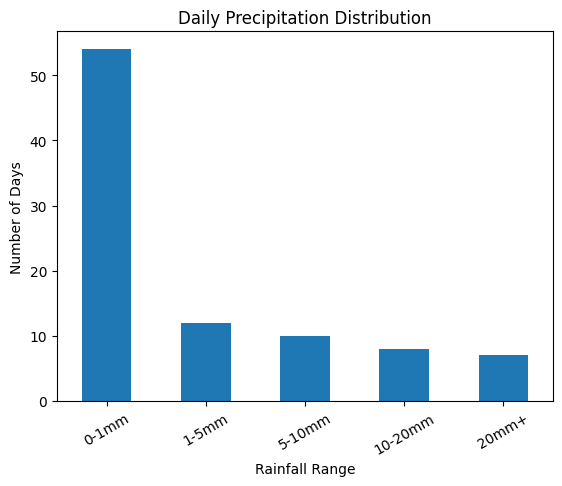

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt


# daily_precip = df_weather["precipitation"].resample("D").sum()

# rainy_days = (daily_precip > 0).sum()
# non_rainy_days = (daily_precip == 0).sum()

# print("Rainy days:", rainy_days)
# print("Non-rainy days:", non_rainy_days)

# plt.figure()
# plt.pie(
#     [rainy_days, non_rainy_days],
#     labels=["Rainy", "Non-Rainy"],
#     autopct="%1.1f%%"
# )
# plt.title("Rainy vs Non-Rainy Days")
# plt.show()


# bins = [0, 1, 5, 10, 20, 50]
# labels = ["0-1mm", "1-5mm", "5-10mm", "10-20mm", "20mm+"]

# rain_distribution = pd.cut(
#     daily_precip,
#     bins=bins,
#     labels=labels,
#     include_lowest=True
# ).value_counts().sort_index()


# plt.figure()
# plt.pie(
#     rain_distribution,
#     labels=rain_distribution.index,
#     autopct="%1.1f%%"
# )
# plt.title("Daily Precipitation Distribution")
# plt.show()


# plt.figure()
# rain_distribution.plot(kind="bar")
# plt.title("Daily Precipitation Distribution")
# plt.xlabel("Rainfall Range")
# plt.ylabel("Number of Days")
# plt.xticks(rotation=30)
# plt.show()


In [ ]:
import h5py
import numpy as np
def generate_seq2seq_data(df, x_offsets, y_offsets, add_time_in_day=True, add_day_in_week=True):
    num_samples, num_nodes = df.shape[0], df.shape[1]
    pass


def generate_train_val_test(h5_path = 'nyc-taxi.h5', past = 12, future = 12):
    df = h5py.File(h5_path, 'r')
    rawdata = []
 
    for key in ["taxi_pick","taxi_drop"]:
        data = np.array(df[key])
        rawdata.append(data)
    # list变为numpy，第三维含义：[:, :, 0]=pick（上客量），[:, :, 1]=drop（下客量）
    rawdata = np.stack(rawdata, -1) # (num_samples, num_nodes, 2)

    x_offsets = np.arange(-past + 1, 1)  # e.g., [-11, -10, ..., -1, 0]
    y_offsets = np.arange(1, future + 1)  # e.g., [1, 2, ..., 11, 12]

    x, y = generate_seq2seq_data(df, x_offsets, y_offsets)
    
    
    pass

In [ ]:
def generate_train_val_test(args):
    """
    完整的数据处理流程：
      1. 读取 HDF5 文件中的 pick（上客）和 drop（下客）两类特征；
      2. 调用 generate_graph_seq2seq_io_data 生成滑动窗口样本；
      3. 按时间顺序将样本划分为训练集/验证集/测试集；
      4. 将每个子集保存为压缩的 .npz 文件。

    参数：
        args.h5_name : str，HDF5 文件名（不含 .h5 后缀），也作为输出目录名。
                       HDF5 内部 key 由文件名最后 4 字符拼接特征名构成，
                       例如 "nyc-taxi" → "taxi_pick" / "taxi_drop"。
        args.window  : int，历史序列长度（输入步数）。
        args.horizon : int，预测序列长度（输出步数）。
    """

    # ------------------------------------------------------------------

  
    # ------------------------------------------------------------------
    # Step 3：用滑动窗口生成所有样本
    # ------------------------------------------------------------------
    x, y = generate_graph_seq2seq_io_data(
        rawdata,
        x_offsets=x_offsets,
        y_offsets=y_offsets,
        add_time_in_day=False,   # 当前不使用时间特征
        add_day_in_week=False,   # 当前不使用星期特征
    )
    # x: (num_samples, input_length,  num_nodes, input_dim=2)
    # y: (num_samples, output_length, num_nodes, output_dim=2)
    print("x shape: ", x.shape, ", y shape: ", y.shape)

    # ------------------------------------------------------------------
    # Step 4：按时间顺序划分训练/验证/测试集
    # ------------------------------------------------------------------
    # 注意：必须按时间顺序切分，不可随机打乱，否则会造成数据泄露
    num_samples = x.shape[0]

    num_test  = 672   # 测试集样本数（672 步 ÷ 24步/天 = 28天，约 4 周）
    num_val   = 672   # 验证集样本数（同上）
    num_train = num_samples - num_test - num_val  # 其余全部作为训练集

    # 训练集：最早的 num_train 个样本
    x_train, y_train = x[:num_train], y[:num_train]

    # 验证集：紧接训练集之后的 num_val 个样本
    x_val, y_val = (
        x[num_train: num_train + num_val],
        y[num_train: num_train + num_val],
    )

    # 测试集：时间上最靠后的 num_test 个样本
    x_test, y_test = x[-num_test:], y[-num_test:]

    # ------------------------------------------------------------------
    # Step 5：保存为压缩 .npz 文件
    # ------------------------------------------------------------------
    # 以数据集名称创建输出目录，例如 ./nyc-taxi/
    save_folder = os.path.join(args.h5_name)
    os.mkdir(save_folder)

    for cat in ["train", "val", "test"]:
        _x, _y = locals()["x_" + cat], locals()["y_" + cat]
        print(cat, "x: ", _x.shape, "y:", _y.shape)
        np.savez_compressed(
            os.path.join(save_folder, "%s.npz" % cat),
            x=_x,
            y=_y,
            # 偏移量额外添加一个尾部维度 [T, 1]，
            # 供下游模型直接索引使用
            x_offsets=x_offsets.reshape(list(x_offsets.shape) + [1]),
            y_offsets=y_offsets.reshape(list(y_offsets.shape) + [1]),
        )


In [ ]:
import argparse
import numpy as np
import os
import pandas as pd
import h5py
import requests

# ============================================================
# 数据预处理脚本：将原始 HDF5 时序数据转换为 Seq2Seq 模型
# 所需的 .npz 格式，并划分训练/验证/测试集。
# 新增：从 Open-Meteo 免费 API 获取对应时段 NYC 历史天气特征
#       （降水量、气温、风速），与交通流量时间步对齐后写入 x。
#
# 最终 channel 结构（input_dim=6）：
#   x: [drop流量, time_in_day比例, day_of_week, precipitation, temperature, windspeed]
#   y: [drop流量]  ← 只预测流量，不预测天气
# ============================================================

NYC_LAT = 40.7128   # 纽约市中心纬度（Central Park 附近）
NYC_LON = -74.0060  # 纽约市中心经度


# ---------------------------------------------------------------
# Part 1：天气数据获取
# ---------------------------------------------------------------

def fetch_weather_openmeteo(start_date, end_date, lat=NYC_LAT, lon=NYC_LON):
    """
    从 Open-Meteo 历史存档 API 获取 NYC 逐小时天气，
    上采样至 30 分钟粒度以匹配交通数据的时间步长。

    API 特点：免费、无需注册/密钥，支持全球历史天气（1940 年至今）。

    参数：
        start_date : str，格式 "YYYY-MM-DD"，拉取起始日期
        end_date   : str，格式 "YYYY-MM-DD"，拉取结束日期
        lat, lon   : 城市中心坐标，默认 NYC 中心

    返回：
        df_30min : pd.DataFrame
                   index  = DatetimeIndex，30 分钟频率，时区 America/New_York
                   列     = ["precipitation", "temperature", "windspeed"]
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   lat,
        "longitude":  lon,
        "start_date": start_date,
        "end_date":   end_date,
        # precipitation  : 逐小时降水量（mm），含雨+雪融水
        # temperature_2m : 2 米高度气温（°C）
        # windspeed_10m  : 10 米高度风速（km/h）
        "hourly":     "precipitation,temperature_2m,windspeed_10m",
        "timezone":   "America/New_York",
    }
    print(f"正在从 Open-Meteo 获取 {start_date} 至 {end_date} 的 NYC 历史天气...")
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()

    hourly = resp.json()["hourly"]
    df_hourly = pd.DataFrame(
        {
            "precipitation": hourly["precipitation"],   # 单位：mm/h
            "temperature":   hourly["temperature_2m"],  # 单位：°C
            "windspeed":     hourly["windspeed_10m"],   # 单位：km/h
        },
        index=pd.to_datetime(hourly["time"]),  # 逐小时 DatetimeIndex（本地时区）
    )

    # ------------------------------------------------------------------
    # 上采样：逐小时 → 30 分钟
    #
    # 策略：
    #   precipitation：前向填充后除以 2
    #       每小时的降水量平均分配到两个 30 分钟格（物理上更合理）
    #   temperature, windspeed：线性插值
    #       连续量，两个相邻小时间取中间值
    # ------------------------------------------------------------------
    # 构造覆盖所有小时数据的 30 分钟时间轴
    # 末尾额外延伸 30min，确保最后一个整点的第二个半小时也有数据
    idx_30min = pd.date_range(
        start=df_hourly.index[0],
        end=df_hourly.index[-1] + pd.Timedelta("30min"),
        freq="30min",
    )

    # 先 reindex（整点有值，半点为 NaN），再分别填充
    df_30min = df_hourly.reindex(idx_30min)

    # 气温、风速：线性插值（NaN 处取前后整点均值）
    df_30min[["temperature", "windspeed"]] = (
        df_30min[["temperature", "windspeed"]].interpolate(method="linear")
    )

    # 降水：前向填充（半点继承上一整点的值），再除以 2
    df_30min["precipitation"] = (
        df_hourly["precipitation"].reindex(idx_30min).ffill() / 2.0
    )

    print(f"天气数据获取完成，共 {len(df_30min)} 个 30 分钟时间步")
    return df_30min


# ---------------------------------------------------------------
# Part 2：滑动窗口采样
# ---------------------------------------------------------------

def generate_graph_seq2seq_io_data(
        traffic_data,
        x_offsets,
        y_offsets,
        time_features=None,
        weather_features=None,
        scaler=None,
):
    """
    利用滑动窗口从原始时序数据中构造 Seq2Seq 模型的输入/输出样本。

    设计原则（x 与 y 的 channel 解耦）：
        x（输入）包含全部特征：交通流量 + 时间特征 + 天气特征
        y（标签）只保留交通流量（channel 0），用于计算预测损失

    参数：
        traffic_data    : np.ndarray，形状 (T, N)，交通流量（仅 drop 特征）
        x_offsets       : np.ndarray，历史窗口偏移量，例如 [-11, -10, ..., 0]
        y_offsets       : np.ndarray，预测窗口偏移量，例如 [1, 2, ..., 12]
        time_features   : np.ndarray or None，形状 (T, num_time_feat)
                          时间特征，对全市所有节点共享（广播）
                          示例：[time_in_day_ratio, day_of_week]
        weather_features: np.ndarray or None，形状 (T, num_weather_feat)
                          天气特征，对全市所有节点共享（广播）
                          示例：[precipitation, temperature, windspeed]
        scaler          : 归一化器，保留接口，暂未在函数内部使用

    返回：
        x : np.ndarray，(epoch_size, input_length,  N, input_dim)
        y : np.ndarray，(epoch_size, output_length, N, 1)   ← 仅交通流量
    """
    T, num_nodes = traffic_data.shape

    # ---- 构建 x 的完整特征矩阵 ----
    # channel 0：交通流量，shape (T, N, 1)
    traffic_3d = traffic_data[:, :, np.newaxis].astype(np.float64)
    x_parts = [traffic_3d]

    if time_features is not None:
        # (T, F_time) → 广播到 (T, N, F_time)，所有节点共享同一时间特征
        time_3d = np.tile(time_features[:, np.newaxis, :].astype(np.float64),
                          [1, num_nodes, 1])
        x_parts.append(time_3d)

    if weather_features is not None:
        # (T, F_weather) → 广播到 (T, N, F_weather)，全市统一天气值
        weather_3d = np.tile(weather_features[:, np.newaxis, :].astype(np.float64),
                             [1, num_nodes, 1])
        x_parts.append(weather_3d)

    # x_all：所有特征沿最后一维拼接，shape (T, N, input_dim)
    x_all = np.concatenate(x_parts, axis=-1)

    # y_all：只保留 channel 0（交通流量），shape (T, N, 1)
    y_all = traffic_3d

    print(f"特征矩阵 x_all 形状: {x_all.shape}  "
          f"(input_dim = {x_all.shape[-1]} = "
          f"1 traffic + {time_features.shape[-1] if time_features is not None else 0} time + "
          f"{weather_features.shape[-1] if weather_features is not None else 0} weather)")

    # ---- 滑动窗口采样 ----
    # min_t：历史窗口需要向前看 window 步，因此从 min_t 才能取到完整输入
    min_t = abs(min(x_offsets))
    # max_t：预测窗口不超过数据末尾（不含）
    max_t = T - abs(max(y_offsets))

    x_list, y_list = [], []
    for t in range(min_t, max_t):
        # 历史输入：shape (input_length, N, input_dim)
        x_list.append(x_all[t + x_offsets, ...])
        # 未来标签：shape (output_length, N, 1)
        y_list.append(y_all[t + y_offsets, ...])

    # 堆叠为 batch 维度，axis=0
    x = np.stack(x_list, axis=0)  # (epoch_size, input_length,  N, input_dim)
    y = np.stack(y_list, axis=0)  # (epoch_size, output_length, N, 1)
    return x, y


# ---------------------------------------------------------------
# Part 3：端到端数据生成
# ---------------------------------------------------------------

def generate_train_val_test(args):
    """
    端到端流程：
      1. 从 HDF5 读取 taxi_drop 流量数据
      2. 根据 start_date 生成 30 分钟频率时间戳，提取时间特征
      3. 从 Open-Meteo API 拉取对应时段 NYC 天气，对齐到时间戳
      4. 调用 generate_graph_seq2seq_io_data 生成滑动窗口样本
      5. 按时间顺序划分并保存为压缩 .npz 文件
    """

    # ------------------------------------------------------------------
    # Step 1：读取 HDF5 流量数据（仅 drop 特征）
    # ------------------------------------------------------------------
    h5_path = os.path.join("h5data", args.h5_name + ".h5")
    with h5py.File(h5_path, "r") as f:
        # key 规则：h5_name 最后 4 字符 + "_drop"，例如 "nyc-taxi" → "taxi_drop"
        drop_key = args.h5_name[-4:] + "_drop"
        traffic = np.array(f[drop_key], dtype=np.float64)  # (T, N)

    T, num_nodes = traffic.shape
    print(f"流量数据形状: (T={T}, N={num_nodes})")
    print(f"时间范围: {args.start_date} 至 {args.end_date}，步长 30 分钟")

    # ------------------------------------------------------------------
    # Step 2：生成 30 分钟频率时间戳，提取时间特征
    # ------------------------------------------------------------------
    timestamps = pd.date_range(
        start=args.start_date, periods=T, freq="30min", tz="America/New_York"
    )
    assert len(timestamps) == T, "时间戳数量与数据步数不一致，请检查 start_date"

    # time_in_day：当前步在一天中的比例
    # 计算：(小时 × 60 + 分钟) / 30 得到 0~47 的槽位索引，再除以 48 归一化到 [0, 1)
    # 例：00:00 → 0/48=0.0000，00:30 → 1/48=0.0208，23:30 → 47/48=0.9792
    time_in_day = (timestamps.hour * 60 + timestamps.minute).values / 30.0 / 48.0

    # day_of_week：星期几（0=周一，6=周日），与 pandas dayofweek 一致
    day_of_week = timestamps.dayofweek.values.astype(np.float64)

    # time_features 形状：(T, 2)
    time_features = np.stack([time_in_day, day_of_week], axis=-1)

    # ------------------------------------------------------------------
    # Step 3：获取 NYC 历史天气并对齐到 30 分钟时间步
    # ------------------------------------------------------------------
    weather_df = fetch_weather_openmeteo(args.start_date, args.end_date)

    # 确保时区一致（Open-Meteo 返回的是 naive datetime，需要附加时区）
    if weather_df.index.tz is None:
        weather_df.index = weather_df.index.tz_localize("America/New_York")
    else:
        weather_df.index = weather_df.index.tz_convert("America/New_York")

    # 按 timestamps 对齐；tolerance=31min 容忍 ±1 步的时间偏差
    weather_aligned = weather_df.reindex(
        timestamps, method="nearest", tolerance=pd.Timedelta("31min")
    )

    # 处理极少数可能出现的 NaN（如 DST 时钟拨转导致的缺口）
    if weather_aligned.isnull().any().any():
        missing = weather_aligned.isnull().sum().sum()
        print(f"警告：天气对齐后存在 {missing} 个 NaN，已使用前向/后向填充处理")
        weather_aligned = weather_aligned.ffill().bfill()

    # weather_features 形状：(T, 3) — [precipitation(mm), temperature(°C), windspeed(km/h)]
    weather_features = weather_aligned[["precipitation", "temperature", "windspeed"]].values
    print(f"天气特征形状: {weather_features.shape}")
    print(f"  降水 min/max: {weather_features[:,0].min():.2f} / {weather_features[:,0].max():.2f} mm")
    print(f"  气温 min/max: {weather_features[:,1].min():.2f} / {weather_features[:,1].max():.2f} °C")
    print(f"  风速 min/max: {weather_features[:,2].min():.2f} / {weather_features[:,2].max():.2f} km/h")

    # ------------------------------------------------------------------
    # Step 4：构造时间偏移量，生成滑动窗口样本
    # ------------------------------------------------------------------
    # 历史窗口：[-(window-1), ..., 0]，共 window 步
    x_offsets = np.sort(np.arange(-(args.window - 1), 1, 1))
    # 预测窗口：[1, ..., horizon]，共 horizon 步
    y_offsets = np.sort(np.arange(1, args.horizon + 1, 1))

    x, y = generate_graph_seq2seq_io_data(
        traffic_data=traffic,
        x_offsets=x_offsets,
        y_offsets=y_offsets,
        time_features=time_features,
        weather_features=weather_features,
    )
    # x: (num_samples, window,   N, 6)  6 = 1+2+3
    # y: (num_samples, horizon,  N, 1)
    print(f"\n生成样本 — x: {x.shape}, y: {y.shape}")

    # ------------------------------------------------------------------
    # Step 5：按时间顺序划分训练/验证/测试集，保存 .npz
    # ------------------------------------------------------------------
    # 注意：必须按时间顺序切分，不可随机打乱（防止数据泄露）
    num_samples = x.shape[0]
    num_test  = 672   # 测试集：672 步 ÷ 48 步/天 = 14 天
    num_val   = 672   # 验证集：同上
    num_train = num_samples - num_test - num_val  # 其余全部为训练集
    print(f"样本划分 — train: {num_train}, val: {num_val}, test: {num_test}")

    x_train, y_train = x[:num_train],                    y[:num_train]
    x_val,   y_val   = x[num_train:num_train + num_val], y[num_train:num_train + num_val]
    x_test,  y_test  = x[-num_test:],                    y[-num_test:]

    # 创建输出目录（exist_ok=True 避免已存在时报错）
    save_folder = args.output_dir
    os.makedirs(save_folder, exist_ok=True)

    for cat in ["train", "val", "test"]:
        _x, _y = locals()["x_" + cat], locals()["y_" + cat]
        print(f"  {cat}: x={_x.shape}, y={_y.shape}")
        np.savez_compressed(
            os.path.join(save_folder, f"{cat}.npz"),
            x=_x,
            y=_y,
            # 保存偏移量，供下游模型读取（添加尾部维度以便直接索引）
            x_offsets=x_offsets.reshape(-1, 1),
            y_offsets=y_offsets.reshape(-1, 1),
        )
    print(f"\n所有文件已保存至 ./{save_folder}/")


def main(args):
    print("=" * 60)
    print("开始生成带天气特征的训练数据")
    print("=" * 60)
    generate_train_val_test(args)


if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="将 HDF5 时序数据预处理为含天气特征的 Seq2Seq .npz 训练文件"
    )
    parser.add_argument(
        "--h5_name", type=str, default="nyc-taxi",
        help="HDF5 数据文件名（不含 .h5），同时决定内部 key 前缀（如 taxi_drop）",
    )
    parser.add_argument(
        "--start_date", type=str, default="2016-04-01",
        help="数据集起始日期（YYYY-MM-DD），用于生成时间戳并拉取天气",
    )
    parser.add_argument(
        "--end_date", type=str, default="2016-06-30",
        help="数据集结束日期（YYYY-MM-DD），用于拉取天气",
    )
    parser.add_argument(
        "--window", type=int, default=12,
        help="历史输入序列长度（时间步数），对应 x_offsets 长度",
    )
    parser.add_argument(
        "--horizon", type=int, default=12,
        help="未来预测序列长度（时间步数），对应 y_offsets 长度",
    )
    parser.add_argument(
        "--output_dir", type=str, default="nyc-taxi-weather",
        help="输出 .npz 文件的目录名",
    )

    args = parser.parse_args()
    main(args)
